**IPL ANALYSIS 2008-2024**

**1.Data Loading**

In [ ]:
import pandas as pd
matches=pd.read_csv("/content/matches.csv")
df=pd.DataFrame(matches)
print(df)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  18-04-2008       League      BB McCullum   
1      335983  2007/08  Chandigarh  19-04-2008       League       MEK Hussey   
2      335984  2007/08       Delhi  19-04-2008       League      MF Maharoof   
3      335985  2007/08      Mumbai  20-04-2008       League       MV Boucher   
4      335986  2007/08     Kolkata  20-04-2008       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  19-05-2024       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  21-05-2024  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  22-05-2024   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  24-05-2024  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  26-05-2024        Final         MA Starc   

                                       

**2.Data Cleaning**

In [ ]:
print(df.isnull().sum())
print("\n")
print(df.dtypes)

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1            

In [ ]:
df["city"]=df["city"].fillna("Unknown")
df["player_of_match"]=df["player_of_match"].fillna("Unknown")
df["winner"]=df["winner"].fillna("No result")
df["result_margin"]=df["result_margin"].fillna(0)
df["target_overs"]=df["target_overs"].fillna(0)
df["target_runs"]=df["target_runs"].fillna(0)
df["method"]=df["method"].fillna("Normal")
df["date"]=pd.to_datetime(df["date"])
print(df.isnull().sum())



id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64


/tmp/ipykernel_12767/165088400.py:8: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"]=pd.to_datetime(df["date"])


In [ ]:
changes={"Royal Challengers Bangalore":"Royal Challengers Bengaluru","Kings XI Punjab":"Punjab Kings","Deccan Chargers":"Sunrisers Hyderabad","Delhi Daredevils":"Delhi Capitals","Rising Pune Supergiants":"Rising Pune Supergiant","Bangalore":"Bengaluru"}
df["team1"]=df["team1"].replace(changes)
df["team2"]=df["team2"].replace(changes)
df["winner"]=df["winner"].replace(changes)
df["toss_winner"]=df["toss_winner"].replace(changes)
df["city"]=df["city"].replace(changes)

**Analysis 1: Which team has highest win %**

{'Royal Challengers Bengaluru': 255, 'Punjab Kings': 246, 'Sunrisers Hyderabad': 257, 'Delhi Capitals': 252, 'Chennai Super Kings': 238, 'Rising Pune Supergiant': 30, 'Kochi Tuskers Kerala': 14, 'Mumbai Indians': 261, 'Kolkata Knight Riders': 251, 'Lucknow Super Giants': 44, 'Gujarat Titans': 45, 'Rajasthan Royals': 221, 'Pune Warriors': 46, 'Gujarat Lions': 30}
{'Royal Challengers Bengaluru': 123, 'Punjab Kings': 112, 'Sunrisers Hyderabad': 117, 'Delhi Capitals': 115, 'Chennai Super Kings': 138, 'Rising Pune Supergiant': 15, 'Kochi Tuskers Kerala': 6, 'Mumbai Indians': 144, 'Kolkata Knight Riders': 131, 'Lucknow Super Giants': 24, 'Gujarat Titans': 28, 'Rajasthan Royals': 112, 'Pune Warriors': 12, 'Gujarat Lions': 13}
{'Royal Challengers Bengaluru': 48.23529411764706, 'Punjab Kings': 45.52845528455284, 'Sunrisers Hyderabad': 45.525291828793776, 'Delhi Capitals': 45.63492063492063, 'Chennai Super Kings': 57.98319327731093, 'Rising Pune Supergiant': 50.0, 'Kochi Tuskers Kerala': 42.8571

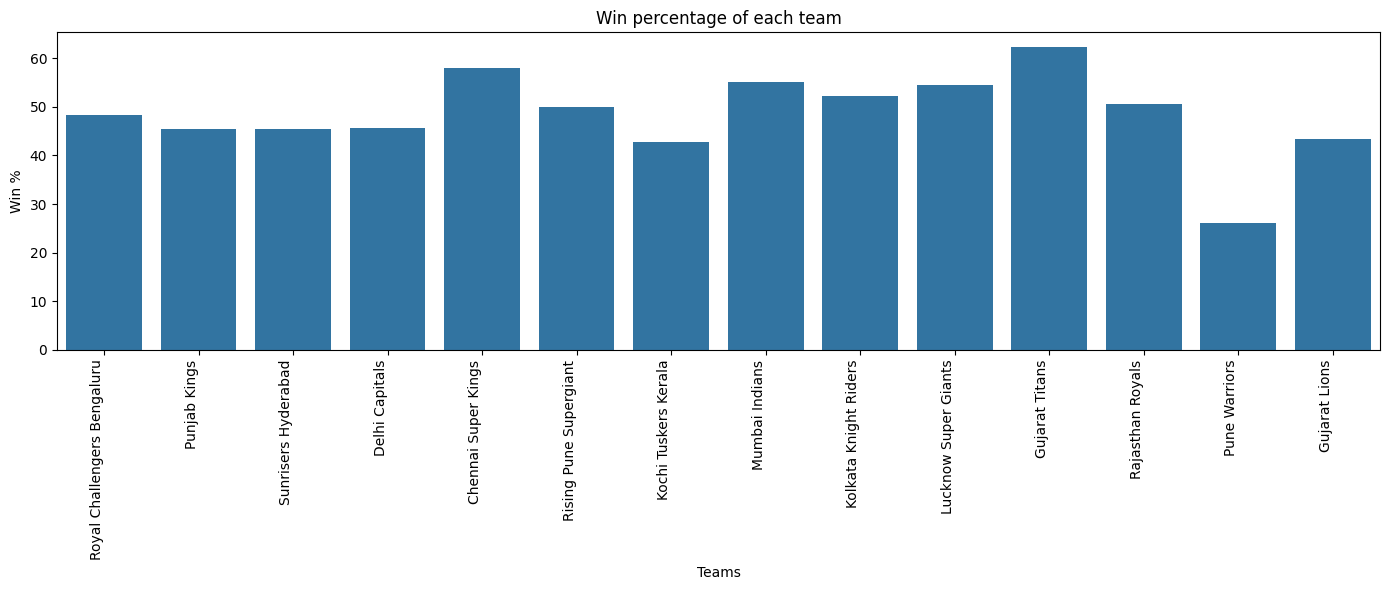

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
win_percentage={"Royal Challengers Bengaluru":0,"Punjab Kings":0,"Sunrisers Hyderabad":0,"Delhi Capitals":0,"Chennai Super Kings":0,"Rising Pune Supergiant":0,"Kochi Tuskers Kerala":0,"Mumbai Indians":0,"Kolkata Knight Riders":0,"Lucknow Super Giants":0,"Gujarat Titans":0,"Rajasthan Royals":0,"Pune Warriors":0,"Gujarat Lions":0}
total_matches={"Royal Challengers Bengaluru":0,"Punjab Kings":0,"Sunrisers Hyderabad":0,"Delhi Capitals":0,"Chennai Super Kings":0,"Rising Pune Supergiant":0,"Kochi Tuskers Kerala":0,"Mumbai Indians":0,"Kolkata Knight Riders":0,"Lucknow Super Giants":0,"Gujarat Titans":0,"Rajasthan Royals":0,"Pune Warriors":0,"Gujarat Lions":0}
no_of_wins={"Royal Challengers Bengaluru":0,"Punjab Kings":0,"Sunrisers Hyderabad":0,"Delhi Capitals":0,"Chennai Super Kings":0,"Rising Pune Supergiant":0,"Kochi Tuskers Kerala":0,"Mumbai Indians":0,"Kolkata Knight Riders":0,"Lucknow Super Giants":0,"Gujarat Titans":0,"Rajasthan Royals":0,"Pune Warriors":0,"Gujarat Lions":0}
for index,rows in df.iterrows():
  t1=rows["team1"]
  t2=rows["team2"]
  winner=rows["winner"]
  if t1 in total_matches:
    total_matches[t1]+=1
  if t2 in total_matches:
    total_matches[t2]+=1
  if winner in no_of_wins:
    no_of_wins[winner]+=1
for key in win_percentage.keys():
  if total_matches[key]>0:
    win_percentage[key]=(no_of_wins[key]/total_matches[key])*100
  else:
    win_percentage[key]=0.0
print(total_matches)
print(no_of_wins)
print(win_percentage)
for key,value in win_percentage.items():
  win_percentage[key]=(no_of_wins[key]/total_matches[key])*100
plt.figure(figsize=(14,6))
sns.barplot(x=win_percentage.keys(),y=win_percentage.values())
plt.xlabel("Teams")
plt.ylabel("Win %")
plt.title("Win percentage of each team")
plt.xticks(rotation=90,ha="right")
plt.tight_layout()
plt.show()

**Conclusion:** *It is found that gujarat titans have higher win percentage when compared to other teams*

**Analysis 2: Which team performs well in home games**

{'Chennai Super Kings': 70.4225352112676, 'Royal Challengers Bengaluru': 48.888888888888886, 'Delhi Capitals': 45.1219512195122, 'Sunrisers Hyderabad': 52.0, 'Rising Pune Supergiant': 45.45454545454545, 'Gujarat Titans': 56.25, 'Punjab Kings': 48.484848484848484, 'Rajasthan Royals': 64.91228070175438, 'Lucknow Super Giants': 50.0, 'Mumbai Indians': 60.747663551401864, 'Pune Warriors': 25.0, 'Gujarat Lions': 30.0, 'Kolkata Knight Riders': 59.09090909090909, 'Kochi Tuskers Kerala': 40.0}
{'Chennai Super Kings': 52.69461077844312, 'Royal Challengers Bengaluru': 47.878787878787875, 'Delhi Capitals': 45.88235294117647, 'Sunrisers Hyderabad': 42.857142857142854, 'Rising Pune Supergiant': 52.63157894736842, 'Gujarat Titans': 65.51724137931035, 'Punjab Kings': 44.44444444444444, 'Rajasthan Royals': 45.73170731707317, 'Lucknow Super Giants': 56.666666666666664, 'Mumbai Indians': 51.298701298701296, 'Pune Warriors': 26.666666666666668, 'Gujarat Lions': 50.0, 'Kolkata Knight Riders': 48.466257668

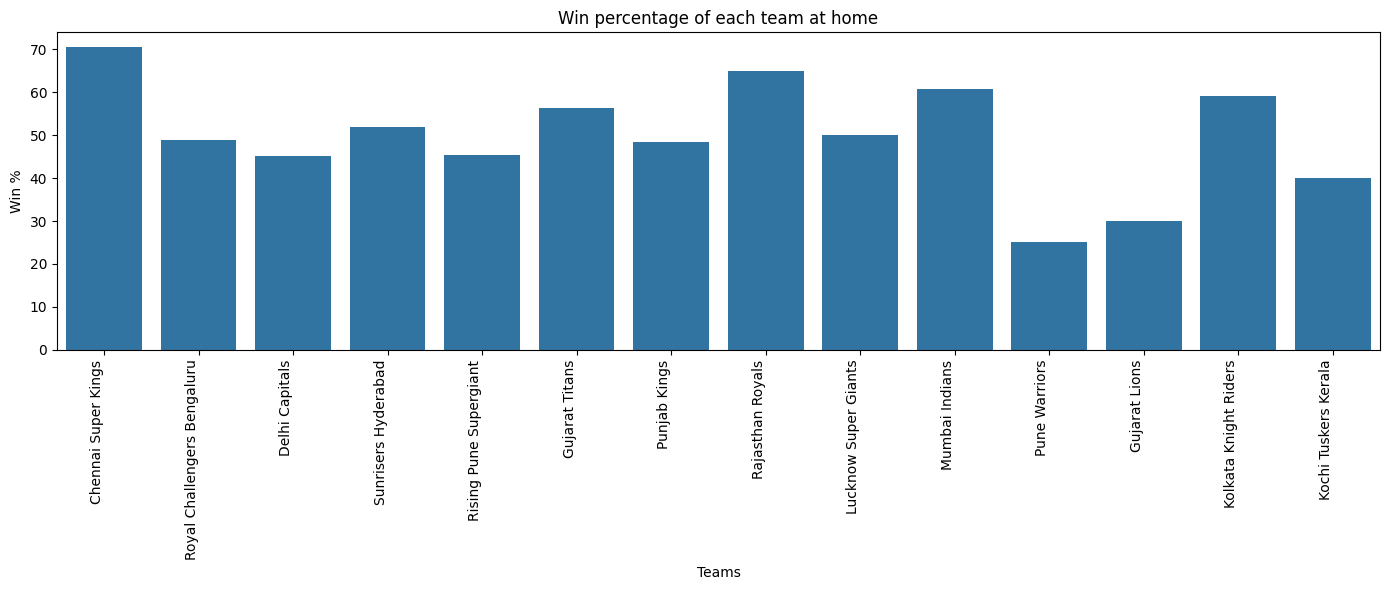

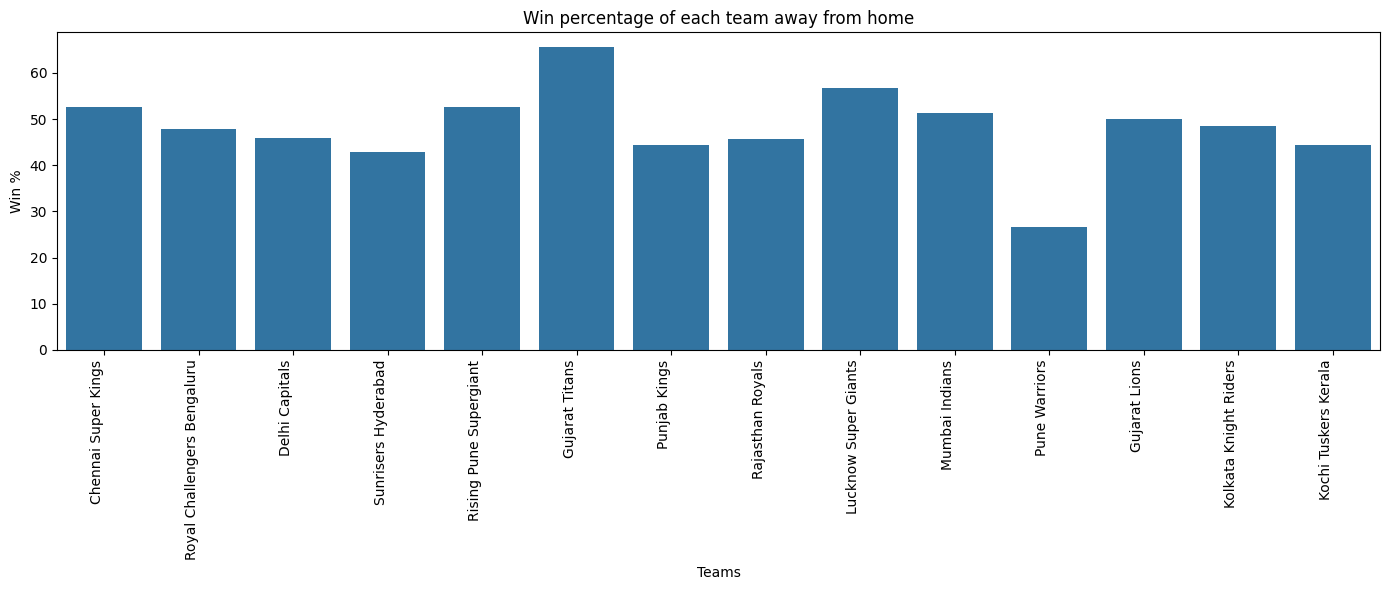

In [ ]:
home_matches={}
away_matches={}
home_wins={}
away_wins={}
home_per={}
away_per={}
home_cities={"Chennai Super Kings":["Chennai"],"Royal Challengers Bengaluru":["Bangalore","Bengaluru"],"Delhi Capitals":["Delhi"],"Sunrisers Hyderabad":["Hyderabad"],"Rising Pune Supergiant":["Pune"],"Gujarat Titans":["Ahmedabad"],"Punjab Kings":["Mohali","Chandigarh"],"Rajasthan Royals":["Jaipur"],"Lucknow Super Giants":["Lucknow"],"Mumbai Indians":["Mumbai","Navi Mumbai"],"Pune Warriors":["Pune"],"Gujarat Lions":["Rajkot"],"Kolkata Knight Riders":["Kolkata"],"Kochi Tuskers Kerala":["Kochi"]}
for key in home_cities.keys():
  home_matches[key]=0
  away_matches[key]=0
  home_wins[key]=0
  away_wins[key]=0
  home_per[key]=0
  away_per[key]=0
for index,row in df.iterrows():
  winner=row["winner"]
  city=row["city"]
  for team in [row["team1"],row["team2"]]:
    if city in home_cities[team]:
      home_matches[team] += 1
      if winner==team:
        home_wins[team] += 1
    else:
      away_matches[team] += 1
      if winner==team:
        away_wins[team] += 1
for key in home_cities.keys():
  if home_matches[key]>0:
    home_per[key]=(home_wins[key]/home_matches[key])*100
  if away_matches[key]>0:
    away_per[key]=(away_wins[key]/away_matches[key])*100
print(home_per)
print(away_per)
plt.figure(figsize=(14,6))
sns.barplot(x=home_per.keys(),y=home_per.values())
plt.xlabel("Teams")
plt.ylabel("Win %")
plt.title("Win percentage of each team at home")
plt.xticks(rotation=90,ha="right")
plt.tight_layout()
plt.show()
plt.figure(figsize=(14,6))
sns.barplot(x=away_per.keys(),y=away_per.values())
plt.xlabel("Teams")
plt.ylabel("Win %")
plt.title("Win percentage of each team away from home")
plt.xticks(rotation=90,ha="right")
plt.tight_layout()
plt.show()

**Conclusion:** *Chennai Super Kings perform well in home games*

**Analysis 3: Does the toss winning really matter?**

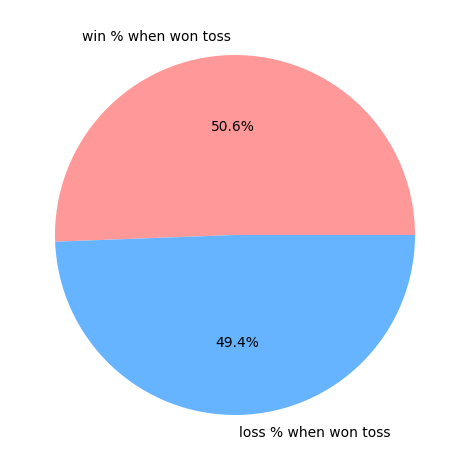

In [ ]:
toss_result=(df["winner"]==df["toss_winner"]).value_counts()
wins=toss_result[True]
losses=toss_result[False]
total=wins+losses
win_per=(wins/total)*100
loss_per=(losses/total)*100
labels=["win % when won toss","loss % when won toss"]
sizes=[win_per,loss_per]
colors=["#ff9999","#66b3ff"]
plt.pie(sizes,labels=labels,colors=colors,autopct="%1.1f%%")
plt.tight_layout()
plt.show()

**Conclusion:** *There isn't significant difference between winning the match when won the toss and losing the match when won the toss. There is almost equal chances of losing and winning the match . Therefore, toss winning doesnt matter much performance does*

**Analysis 4: How did no.of IPL matches change season by season from 2008 to 2024**

{'2007/08': 58, '2009': 57, '2009/10': 60, '2011': 73, '2012': 74, '2013': 76, '2014': 60, '2015': 59, '2016': 60, '2017': 59, '2018': 60, '2019': 60, '2020/21': 60, '2021': 60, '2022': 74, '2023': 74, '2024': 71}


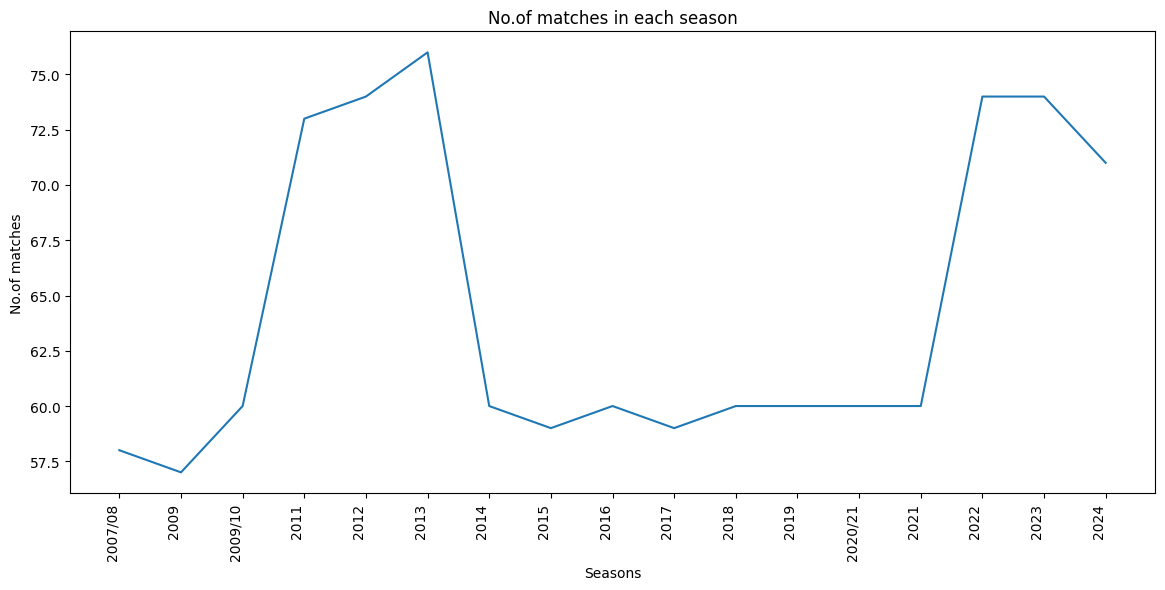

In [ ]:
seasons={}
for index,rows in df.iterrows():
  if rows["season"] not in seasons:
    seasons[rows["season"]]=0
for index,rows in df.iterrows():
  seasons[rows["season"]] += 1
plt.figure(figsize=(14,6))
print(seasons)
sns.lineplot(x=seasons.keys(),y=seasons.values())
plt.xticks(rotation=90,ha="right")
plt.xlabel("Seasons")
plt.ylabel("No.of matches")
plt.title("No.of matches in each season")
plt.show()

Instead can use group by

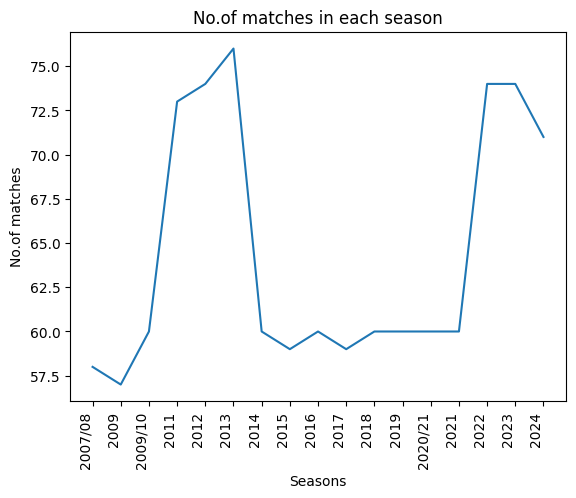

In [ ]:
seasons=df.groupby("season")["id"].count()
sns.lineplot(x=seasons.index,y=seasons.values)
plt.xticks(rotation=90,ha="right")
plt.xlabel("Seasons")
plt.ylabel("No.of matches")
plt.title("No.of matches in each season")
plt.show()

**Conclusion:** *2013 had the highest no.of matches*

**Analysis 5: Player of the match**

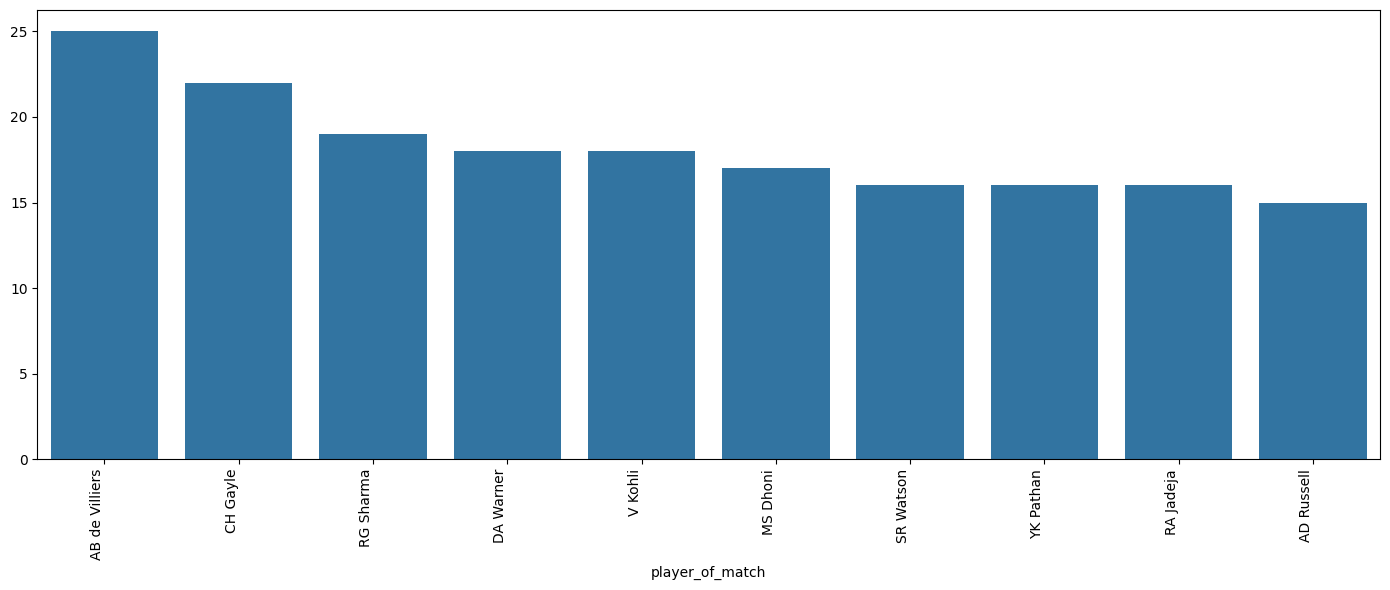

In [29]:
num=df.groupby("player_of_match")["id"].count()
num=num.sort_values(ascending=False)
num=num.head(10)
plt.figure(figsize=(14,6))
sns.barplot(x=num.index,y=num.values)
plt.xticks(rotation=90,ha="right")
plt.tight_layout()
plt.show()

**Conclusion:** *AB de Villiers and Chris Gayle are among the players with the highest number of Player of the Match awards, indicating their consistent match-winning performances across IPL seasons*